In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df =pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
dflocal =pd.read_csv('/content/Churn_Modelling.csv')
dflocal.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [14]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [17]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [18]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True) # need to xplore (it is one hot encoding through pandas library, normally we use OHE throug scikit learn library)

In [19]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [20]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [21]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7389,667,34,5,0.00,2,1,0,163830.64,False,True,False
9275,427,42,1,75681.52,1,1,1,57098.00,True,False,True
2995,535,29,2,112367.34,1,1,0,185630.76,False,False,False
5316,654,40,5,105683.63,1,1,0,173617.09,False,True,True
356,850,57,8,126776.30,2,1,1,132298.49,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9225,594,32,4,120074.97,2,1,1,162961.79,True,False,False
4859,794,22,4,114440.24,1,1,1,107753.07,False,True,False
3264,738,35,5,161274.05,2,1,0,181429.87,False,False,True
9845,590,38,9,0.00,2,1,1,148750.16,False,True,False


In [22]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9394,597,35,8,131101.04,1,1,1,192852.67,True,False,False
898,523,40,2,102967.41,1,1,0,128702.10,False,False,False
2398,706,42,8,95386.82,1,1,1,75732.25,False,True,False
5906,788,32,4,112079.58,1,0,0,89368.59,False,False,True
2343,706,38,5,163034.82,2,1,1,135662.17,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1037,625,24,1,0.00,2,1,1,180969.55,False,False,False
2899,586,35,7,0.00,2,1,0,70760.69,False,False,False
9549,578,36,1,157267.95,2,1,0,141533.19,False,True,True
2740,650,34,4,142393.11,1,1,1,11276.48,True,False,True


In [23]:
y

array([1, 0, 1, ..., 1, 1, 0])

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [26]:
y_test

array([0, 1, 0, ..., 0, 0, 0])

In [27]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [72]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim=11)) # in a first layer(input layer) , it is rule of thumb to always select same number of dense as per no.of columns
model.add(Dense(8,activation='relu'))
model.add(Dense(4,activation='relu')) #(8 , 16 , 32,64,128,256,512,1024 and so on ,rule of thumb)
model.add(Dense(1,activation='relu'))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary() # need to learn param calculation technique

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 8)                   │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 269 (1.05 KB)

 Trainable params: 269 (1.05 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy', metrics=['accuracy'])

In [75]:
history = model.fit(X_train_scaled,y_train,epochs=100, verbose=1, validation_split=0.2) #verbose is to provide isntruction to system for checking epoch customized information, if we add validation no. as well then we get performance of validation accurday and validation loss in addition to training accuracy and training loss ,if validatio not used then on trainig accuracy and trainig loss will be shown

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7544 - loss: 0.6381 - val_accuracy: 0.8075 - val_loss: 0.4614
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8100 - loss: 0.4402 - val_accuracy: 0.8244 - val_loss: 0.4314
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8243 - loss: 0.4155 - val_accuracy: 0.8331 - val_loss: 0.4473
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8400 - loss: 0.3915 - val_accuracy: 0.8381 - val_loss: 0.4441
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8472 - loss: 0.4079 - val_accuracy: 0.8438 - val_loss: 0.4319
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3702 - val_accuracy: 0.8475 - val_loss: 0.4296
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8606 - loss: 0.3749 - val_accuracy: 0.8462 - val_loss: 0.4228
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3688 - val_accu

In [46]:
model.layers[0].get_weights() # 0 in a square brakcer means 2nd layer of our neural network (shows both weights i.e weight and biases)

[array([[ 0.03492684, -0.14698589,  0.10932206,  0.03383486, -0.16543037,
          0.0836033 ,  0.19474098, -0.27028945,  0.07938549,  0.1907704 ,
          0.23311546],
        [ 0.03342633, -0.32472003,  0.14019339, -0.6433968 , -0.7887722 ,
         -0.56091434,  0.5721132 , -0.53513724,  0.22948468,  0.34557027,
         -0.01453164],
        [ 0.06682875, -0.0626987 ,  0.29775715,  0.01843191, -0.26268536,
          0.05835621,  0.04549985, -0.15481815, -0.4817578 ,  0.30782607,
          0.10295629],
        [-0.33552238,  0.20942654, -0.090496  ,  0.23458388,  0.31311712,
          0.03204669, -0.1801337 , -0.5891329 ,  0.10329245,  0.11467332,
         -0.29562193],
        [-1.0887511 ,  1.0546653 ,  0.2119741 , -0.14130698, -0.18103884,
          0.06871678,  0.23579772,  0.21390773, -0.06119841,  0.6629321 ,
          0.8293606 ],
        [ 0.06733225, -0.08901127,  0.13646112,  0.25230068, -0.57272965,
          0.09057911,  0.14794572, -0.20516908, -0.43517554,  0.3288121

In [48]:
model.layers[1].get_weights() # 1 in a square brakcer means 2nd layer of our neural network (shows both weights i.e weight and biases)

[array([[ 0.6831361 ,  0.0045627 , -0.1745084 , -0.17608571, -0.47757417,
         -0.26928785,  0.3427803 , -0.34010983],
        [-0.144286  ,  0.01580497, -0.11578424,  0.43423477,  0.55090594,
          0.18037538,  0.78865683, -0.5429843 ],
        [-0.32073703,  0.04513475,  0.20562705, -0.23616184,  0.3646972 ,
         -0.34884563, -0.17955212,  0.32574725],
        [-0.10719055,  0.32913306,  0.02740343, -0.22193845,  0.75111145,
          0.22412549, -0.07715202,  0.04154661],
        [-0.37573853, -0.06648307,  0.330054  , -0.5133185 ,  0.29662266,
          0.26165485, -0.35701275, -0.33699363],
        [-0.46814382, -0.4621389 ,  0.32909775, -0.51984614,  0.3362553 ,
         -0.20410635, -0.5045921 ,  0.5869931 ],
        [ 0.11487709,  0.09906732,  0.04735662, -0.20624107, -0.2732074 ,
          0.0989986 , -0.11531305,  0.56929547],
        [ 0.4819128 ,  0.24969244,  0.2565126 , -0.05501001, -0.05727845,
         -0.41857767, -0.31849754,  0.6410253 ],
        [ 0.1315

In [49]:
model.layers[2].get_weights() # 2 in a square brakcer means 2nd layer of our neural network (shows both weights i.e weight and biases)

[array([[ 0.7221994 ,  0.34549174, -0.18872575, -0.7953205 ],
        [ 0.05455124, -0.5153002 ,  0.43367666, -0.12263241],
        [ 0.2702431 , -0.5595335 ,  0.6068632 , -0.1840252 ],
        [ 0.39255702,  1.0194093 ,  0.00248023, -0.1286792 ],
        [-0.39253658,  0.0816176 ,  0.84439564,  0.15416464],
        [ 0.09394044,  0.33126006, -0.55682945,  0.04266826],
        [ 0.0750626 ,  1.3781706 , -0.7031305 , -0.5454053 ],
        [-0.5290056 , -0.32224244,  0.34581807,  0.73712885]],
       dtype=float32),
 array([ 0.01059982, -0.06160995,  0.2574621 ,  0.1978614 ], dtype=float32)]

In [55]:
model.layers[3].get_weights() # 3 in a square brakcer means 2nd layer of our neural network (shows both weights i.e weight and biases)

[array([[ 1.2345581 ],
        [ 0.8561861 ],
        [-0.74956894],
        [-0.9047391 ]], dtype=float32),
 array([-0.13025141], dtype=float32)]

In [76]:
ylog= model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [77]:
y_pred= np.where(ylog > 0.5,1,0) # in logistice regression or binary classification if prediction is <=0.5 it means it is zero or elase it is one

In [78]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [79]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.857

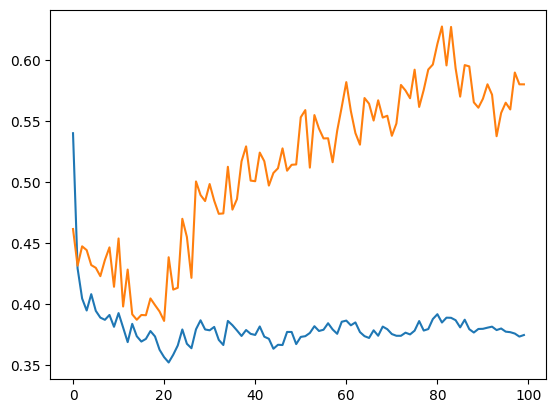

In [80]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

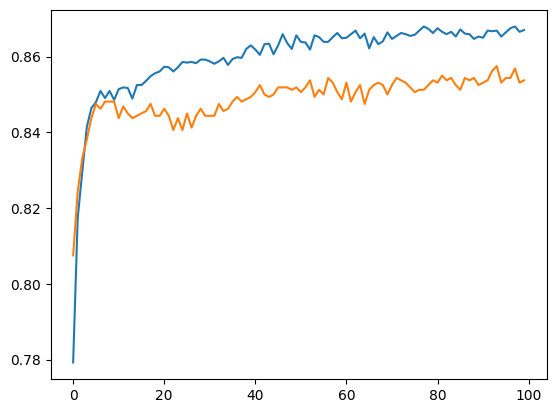

In [81]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

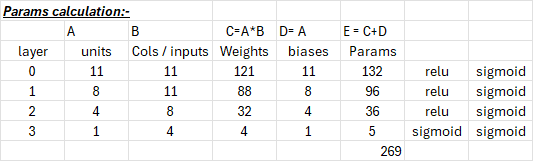